# Assignment 2: SVM using Machine Learning Library

Trong Assignment 2, mô hình SVM được huấn luyện bằng thư viện học máy thay vì tự cài đặt từ đầu. Bài này sử dụng `LinearSVC` từ scikit-learn để huấn luyện mô hình SVM tuyến tính trên bộ dữ liệu Chest X-Ray Images (Pneumonia).

Để so sánh công bằng với Assignment 1, dữ liệu được tiền xử lý giống nhau: ảnh được chuyển sang grayscale, resize về kích thước 128 × 128, chuẩn hóa pixel về khoảng [0, 1] và flatten thành vector 16.384 chiều.

Theo quy ước của Assignment 1, NORMAL được mã hóa là 1 và PNEUMONIA được mã hóa là -1. Khi tính Precision, Recall và F1-score, PNEUMONIA được xem là positive class.

In [1]:
import os
from data_utils import count_images, collect_data

BASE_DIR = r"C:\Users\Admin\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray"

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("Train NORMAL exists:", os.path.exists(os.path.join(BASE_DIR, "train", "NORMAL")))
print("Train PNEUMONIA exists:", os.path.exists(os.path.join(BASE_DIR, "train", "PNEUMONIA")))

BASE_DIR exists: True
Train NORMAL exists: True
Train PNEUMONIA exists: True


In [2]:
train_counts = count_images(BASE_DIR, "train")
val_counts = count_images(BASE_DIR, "val")
test_counts = count_images(BASE_DIR, "test")

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

total_images = sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())
print("Total images:", total_images)

Train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Validation: {'NORMAL': 8, 'PNEUMONIA': 8}
Test: {'NORMAL': 234, 'PNEUMONIA': 390}
Total images: 5856


In [3]:
X_train, y_train = collect_data(BASE_DIR, "train")
X_val, y_val = collect_data(BASE_DIR, "val")
X_test, y_test = collect_data(BASE_DIR, "test")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loading test - PNEUMONIA: 100%|██████████| 390/390 [00:03<00:00, 106.10it/s]

X_train shape: (5216, 16384)
y_train shape: (5216,)
X_val shape: (16, 16384)
y_val shape: (16,)
X_test shape: (624, 16384)
y_test shape: (624,)


Lưu kết quả Assignment 1 để so sánh:

In [4]:
implemented_svm_test_metrics = {
    "Accuracy": 0.7227564102448276,
    "Precision": 0.6954954954829641,
    "Recall": 0.9897435897182116,
    "F1": 0.8169312120663589
}

implemented_svm_confusion_matrix = [
    [65, 169],
    [4, 386]
]

Train SVM bằng thư viện:

In [5]:
from sklearn.svm import LinearSVC

library_svm_model = LinearSVC(
    C=1.0,
    max_iter=10000,
    random_state=42
)

library_svm_model.fit(X_train, y_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

Dự đoán

In [6]:
y_val_pred_library = library_svm_model.predict(X_val)
y_test_pred_library = library_svm_model.predict(X_test)

Evaluate bằng sklearn:

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_library_model(y_true, y_pred, pos_label=-1):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

Validation:

In [8]:
library_svm_val_metrics = evaluate_library_model(
    y_val,
    y_val_pred_library,
    pos_label=-1
)

print("Validation metrics of Library SVM")

for metric_name, metric_value in library_svm_val_metrics.items():
    print(f"{metric_name}: {metric_value}")

Validation metrics of Library SVM
Accuracy: 0.8125
Precision: 0.7272727272727273
Recall: 1.0
F1: 0.8421052631578947


Test:

In [9]:
library_svm_test_metrics = evaluate_library_model(
    y_test,
    y_test_pred_library,
    pos_label=-1
)

print("Test metrics of Library SVM")

for metric_name, metric_value in library_svm_test_metrics.items():
    print(f"{metric_name}: {metric_value}")

Test metrics of Library SVM
Accuracy: 0.7451923076923077
Precision: 0.7134935304990758
Recall: 0.9897435897435898
F1: 0.8292158968850698


Confusion matrix cho Assignment 2:

In [10]:
import numpy as np

def confusion_matrix_binary(y_true, y_pred):
    normal_to_normal = np.sum((y_true == 1) & (y_pred == 1))
    normal_to_pneumonia = np.sum((y_true == 1) & (y_pred == -1))
    pneumonia_to_normal = np.sum((y_true == -1) & (y_pred == 1))
    pneumonia_to_pneumonia = np.sum((y_true == -1) & (y_pred == -1))

    return np.array([
        [normal_to_normal, normal_to_pneumonia],
        [pneumonia_to_normal, pneumonia_to_pneumonia]
    ])

library_svm_confusion_matrix = confusion_matrix_binary(
    y_test,
    y_test_pred_library
)

print(library_svm_confusion_matrix)

[[ 79 155]
 [  4 386]]


So sánh:

In [11]:
import pandas as pd

comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Implemented SVM": [
        implemented_svm_test_metrics["Accuracy"],
        implemented_svm_test_metrics["Precision"],
        implemented_svm_test_metrics["Recall"],
        implemented_svm_test_metrics["F1"]
    ],
    "Library SVM": [
        library_svm_test_metrics["Accuracy"],
        library_svm_test_metrics["Precision"],
        library_svm_test_metrics["Recall"],
        library_svm_test_metrics["F1"]
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Metric,Implemented SVM,Library SVM
0,Accuracy,0.722756,0.745192
1,Precision,0.695495,0.713494
2,Recall,0.989744,0.989744
3,F1,0.816931,0.829216


Vẽ biểu đồ:

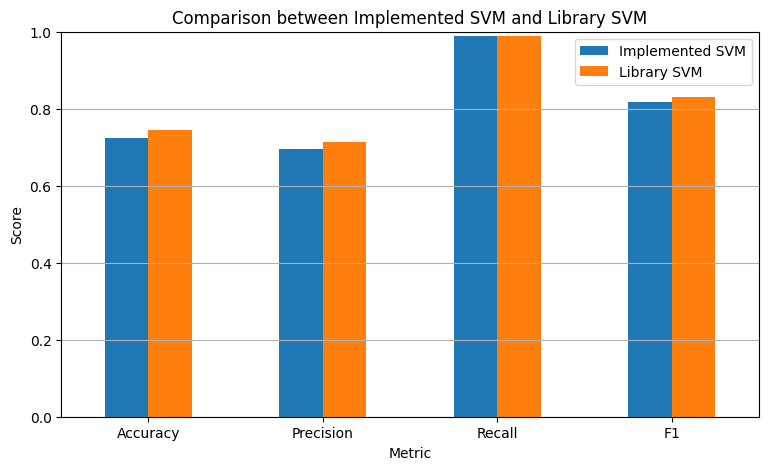

In [12]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Metric",
    y=["Implemented SVM", "Library SVM"],
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.title("Comparison between Implemented SVM and Library SVM")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In hai confusion matrix cạnh nhau:

In [13]:
print("Implemented SVM confusion matrix")
print(np.array(implemented_svm_confusion_matrix))

print("Library SVM confusion matrix")
print(library_svm_confusion_matrix)

Implemented SVM confusion matrix
[[ 65 169]
 [  4 386]]
Library SVM confusion matrix
[[ 79 155]
 [  4 386]]
